# 04_203 · Cascada Transformer con cuatro categorías

Variante reproducible de `04_4`. La primera etapa distingue `SEGURO`/daño y la segunda clasifica cuatro daños: `RACISMO_DISCRIMINACION`, `ACOSO_GENERO_IDENTIDAD`, `ACOSO_AMENAZA` y `CONTENIDO_SEXUAL`. `ACOSO_AMENAZA` fusiona acoso personal y amenaza directa.

Por defecto reutiliza el Transformer afinado en `04_2` como inicialización, pero vuelve a entrenar las etapas y recalibra todos los umbrales. La puerta aprovecha todos los chunks `SEGURO` cuyo video no pertenece a validation/test, incluidos videos seguros que quedaron fuera del submuestreo 4:1; validation y test permanecen congelados.

El mismo arranque funciona localmente y en Colab. En Colab clona una versión fija del código en `/content` y enlaza `datos`, `modelos` y `resultados` al paquete mínimo persistente de Google Drive.

In [1]:
from pathlib import Path
from importlib.util import find_spec
import json, os, shutil, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

REPO_URL = 'https://github.com/lkoc/Trabajo_PLN-MIA-Grupo4.git'
GIT_COMMIT = 'ce33b5efd797eef0809e9ff8694c90220cd81e9d'
PROJECT_NAME, DRIVE_BUNDLE_NAME, NEEDS_PEFT = 'Trabajo_PLN-MIA-Grupo4', 'PLN_colab_04_artifacts', False

def _bootstrap_04_20x():
    in_colab = find_spec('google.colab') is not None
    if not in_colab:
        start = Path.cwd().resolve()
        root = next((p for p in (start, *start.parents) if (p / 'scripts_auxiliares').is_dir()), None)
        if root is None: raise FileNotFoundError('No se encontró la raíz local del proyecto.')
        return root, False, root, 'working-tree-local'
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    artifacts = Path('/content/drive/MyDrive') / DRIVE_BUNDLE_NAME
    manifest_path = artifacts / 'MANIFIESTO_ARTEFACTOS_04_20X.json'
    if not manifest_path.is_file(): raise FileNotFoundError('Falta el bundle de Drive; ejecute sincronizar_04_20x_google_drive.ps1 en Windows.')
    manifest = json.loads(manifest_path.read_text(encoding='utf-8-sig'))
    missing = [r['path'] for r in manifest['files'] if not (artifacts / r['path']).is_file()]
    if missing: raise FileNotFoundError('Bundle incompleto en Drive:\n' + '\n'.join(missing))
    root = Path('/content') / PROJECT_NAME
    if not (root / '.git').is_dir():
        if root.exists(): raise RuntimeError(f'Ruta no administrada ya existente: {root}')
        subprocess.run(['git', 'clone', '--filter=blob:none', '--no-checkout', REPO_URL, str(root)], check=True)
    current = subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True).strip()
    if current != GIT_COMMIT:
        subprocess.run(['git', '-C', str(root), 'fetch', '--depth', '1', 'origin', GIT_COMMIT], check=True)
    subprocess.run(['git', '-C', str(root), 'sparse-checkout', 'set', 'scripts_auxiliares'], check=True)
    subprocess.run(['git', '-C', str(root), 'checkout', '--detach', GIT_COMMIT], check=True)
    for name in ('datos', 'modelos', 'resultados'):
        local, target = root / name, artifacts / name
        target.mkdir(parents=True, exist_ok=True)
        if local.is_symlink() and local.resolve() == target.resolve(): continue
        if local.is_symlink(): local.unlink()
        elif local.exists(): raise RuntimeError(f'Ruta de artefactos no administrada: {local}')
        local.symlink_to(target, target_is_directory=True)
    return root, True, artifacts, GIT_COMMIT

ROOT, IN_COLAB, ARTIFACT_ROOT, CODE_VERSION = _bootstrap_04_20x()
if IN_COLAB:
    packages = {'transformers': 'transformers>=4.51,<6', 'sklearn': 'scikit-learn>=1.4'}
    if NEEDS_PEFT: packages['peft'] = 'peft>=0.15,<1'
    missing_packages = [p for m, p in packages.items() if find_spec(m) is None]
    if missing_packages: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages], check=True)
os.environ['PLN_PROJECT_ROOT'], os.environ['PLN_ARTIFACT_ROOT'] = str(ROOT), str(ARTIFACT_ROOT)
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

from scripts_auxiliares import experimentos_jerarquicos_4 as h4

print('Entorno:', 'Google Colab híbrido' if IN_COLAB else 'local')
print('Código:', ROOT, CODE_VERSION)
print('Artefactos persistentes:', ARTIFACT_ROOT)
print('Dispositivo:', h4.device())
print('Objetivos:', h4.TARGET_LABELS)

Mounted at /content/drive
Entorno: Google Colab híbrido
Código: /content/Trabajo_PLN-MIA-Grupo4 ce33b5efd797eef0809e9ff8694c90220cd81e9d
Artefactos persistentes: /content/drive/MyDrive/PLN_colab_04_artifacts
Dispositivo: cuda
Objetivos: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']


## 1. Datos y transferencia de pesos

La carga verifica por SHA-256 el dataset, el manifiesto, la referencia plana y sus scores. El Transformer de inicio se selecciona sólo por PR-AUC macro de cuatro daños en validation; test no participa. Si en el futuro existe un checkpoint jerárquico original compatible, se priorizará; de lo contrario se usa el ganador plano de `04_2`.

In [2]:
context = h4.load_frozen_context()
display(h4.context_summary(context))
display(h4.warm_start_plan(context))

counts = pd.DataFrame({
    split: h4.four_targets(frame).sum(axis=0).astype(int)
    for split, frame in context['frames'].items()
}, index=h4.TARGET_LABELS)
display(counts)

,split,chunks,videos,con_daño,seguros,chunk_ids_sha256
0,train,24701,2086,4944,19757,9132a1678e24c9bb29d06fcbc1a44d8fb0c54737e571fe...
1,validation,5324,448,1078,4246,571e3e1b829ce1ee2a2f7143bddd99bca67833389b9f47...
2,test,5290,448,1041,4249,9c9c1880e5aa1573754562e1054cc8796e235a99fa4256...


{'enabled_by_default': True,
 'selected_by_validation': 'e5_small',
 'selected_model_label': 'Multilingual E5-small (linaje MiniLM) · unión post hoc a cuatro daños',
 'validation_damage_pr_auc_macro_four_labels': 0.5208643228699481,
 'checkpoint': {'path': 'modelos/moderador_transformer_grueso/e5_small/best_checkpoint.pt',
  'sha256': '8220c22d92304547d26b8b05f245c2347f75570ae4e2f04337207328e3a6ef5d',
  'bytes': 470707208},
 'reuse': {'encoder': 'copied from the selected 04_2 checkpoint',
  'unchanged_category_rows': [0, 1, 4],
  'ACOSO_AMENAZA_row': 'mean of former rows 2 and 3; retrained afterwards',
  'binary_head': 'random unless a compatible old hierarchical checkpoint exists',
  'thresholds': 'never reused; recalibrated on validation'},
 'old_hierarchical_checkpoints_present': {'binary_gate': [],
  'conditional_categories': [],
  'joint_hierarchical': []}}

,train,validation,test
RACISMO_DISCRIMINACION,1319,281,256
ACOSO_GENERO_IDENTIDAD,1394,304,263
ACOSO_AMENAZA,2077,488,463
CONTENIDO_SEXUAL,1613,334,335


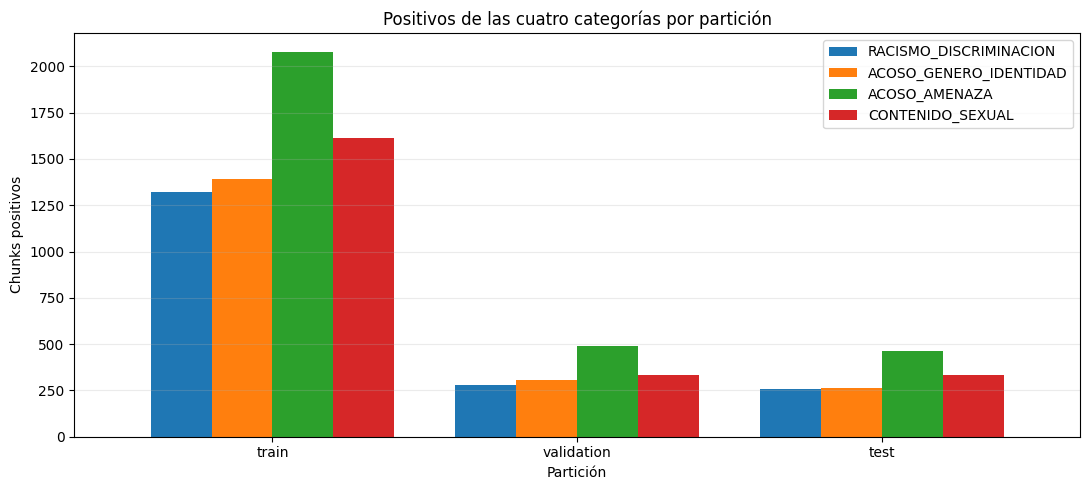

In [3]:
ax = counts.T.plot.bar(figsize=(11, 5), width=0.8)
ax.set_title('Positivos de las cuatro categorías por partición')
ax.set_ylabel('Chunks positivos')
ax.set_xlabel('Partición')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Diseño

La puerta binaria se entrena para obtener alta sensibilidad a cualquier daño. La segunda etapa usa todos los daños y una muestra 1:1 de `SEGURO`, dividida entre negativos difíciles para la puerta y negativos reproducibles por hash. Su score final es `p(daño) × p(categoría | puerta)`.

La transferencia reutiliza el encoder de E5 previamente afinado. Las filas de racismo, género y sexual se copian como inicialización; la fila de `ACOSO_AMENAZA` empieza con el promedio de las antiguas filas de acoso y amenaza y luego se optimiza. La cabeza binaria es nueva porque una OR de cinco logits no equivale a un único logit lineal. Ningún umbral anterior se reutiliza.

La comparación usa la referencia plana convertida a cuatro categorías mediante `max(p_acoso, p_amenaza)` y recalibra el umbral en validation. El máximo evita imponer una independencia no demostrada entre ambas salidas. Ambos sistemas usan el mismo validation/test. Los IC 95% se obtienen con bootstrap pareado por `video_id`; esto preserva la dependencia entre chunks del mismo video.

In [4]:
WARM_START = True
EXPANDED_SAFE_GATE = True
FORCE = False
BOOTSTRAP_REPLICATES = 1_000

print({
    'warm_start': WARM_START,
    'expanded_safe_gate': EXPANDED_SAFE_GATE,
    'force': FORCE,
    'bootstrap_replicates': BOOTSTRAP_REPLICATES,
})

{'warm_start': True, 'expanded_safe_gate': True, 'force': False, 'bootstrap_replicates': 1000}


## 3. Reentrenamiento

La celda muestra barras por época, evaluación y bootstrap. Guarda el mejor checkpoint de la puerta y de la segunda etapa, historiales CSV, scores, figuras, comparación, resultado JSON e informe Markdown. Con `FORCE=False`, un resultado compatible ya terminado sólo se carga.

In [5]:
result = h4.run_cascade_experiment(
    force=FORCE,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
    expanded_safe_gate=EXPANDED_SAFE_GATE,
    warm_start=WARM_START,
)
display({
    'experimento': result['experiment_label'],
    'inicializacion_puerta': result['training']['gate']['initialization'],
    'inicializacion_categorias': result['training']['conditional_categories']['initialization'],
    'datos_puerta': result['training']['gate']['training_data'],
    'decision': result['decision'],
})

{'experimento': 'Cascada binaria → cuatro daños, SEGURO ampliado',
 'inicializacion_puerta': {'enabled': True,
  'role': 'binary_gate',
  'strategy': 'warm_start_from_04_2_flat_transformer',
  'source': {'path': 'modelos/moderador_transformer_grueso/e5_small/best_checkpoint.pt',
   'sha256': '8220c22d92304547d26b8b05f245c2347f75570ae4e2f04337207328e3a6ef5d',
   'bytes': 470707208},
  'source_epoch': 3,
  'copied': ['domain_finetuned_backbone'],
  'head_merge': 'mean of ACOSO_PERSONAL and AMENAZA_DIRECTA rows',
  'random_components': ['binary_head']},
 'inicializacion_categorias': {'enabled': True,
  'role': 'conditional_categories',
  'strategy': 'warm_start_from_04_2_flat_transformer',
  'source': {'path': 'modelos/moderador_transformer_grueso/e5_small/best_checkpoint.pt',
   'sha256': '8220c22d92304547d26b8b05f245c2347f75570ae4e2f04337207328e3a6ef5d',
   'bytes': 470707208},
  'source_epoch': 3,
  'copied': ['mapped_category_head'],
  'head_merge': 'mean of ACOSO_PERSONAL and AMENAZA

,epoch,training_loss,validation_binary_pr_auc,validation_recall_threshold
0,1,3.152273,0.654177,0.013880
1,2,2.958188,0.686573,0.007875
2,3,2.284486,0.691839,0.006028


,epoch,training_loss,validation_damage_pr_auc_macro,validation_damage_f1_macro,thresholds
0,1,0.600257,0.430158,0.413555,"[0.22499999999999998, 0.3, 0.2, 0.65]"
1,2,0.448015,0.432844,0.417788,"[0.22499999999999998, 0.5499999999999999, 0.2,..."
2,3,0.386591,0.430292,0.419428,"[0.2, 0.35, 0.175, 0.22499999999999998]"


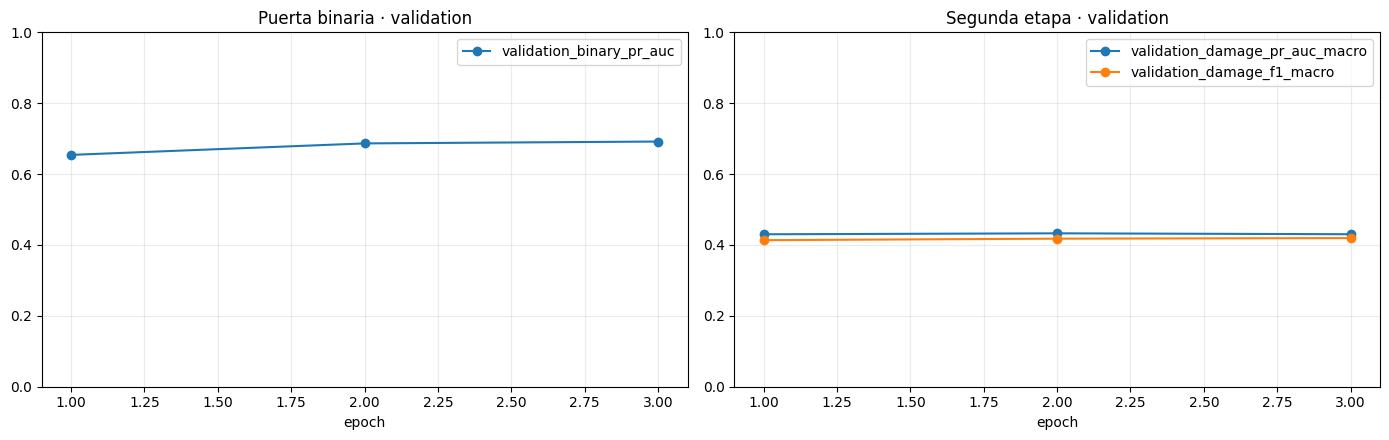

In [6]:
gate_history = pd.DataFrame(result['training']['gate']['history'])
category_history = pd.DataFrame(result['training']['conditional_categories']['history'])
display(gate_history)
display(category_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
gate_history.plot(x='epoch', y='validation_binary_pr_auc', marker='o', ax=axes[0])
category_history.plot(x='epoch', y=['validation_damage_pr_auc_macro', 'validation_damage_f1_macro'], marker='o', ax=axes[1])
axes[0].set_title('Puerta binaria · validation')
axes[1].set_title('Segunda etapa · validation')
for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Resultados y decisión

Una mejora sólo se declara si todo el IC 95% del delta de PR-AUC macro es positivo y el límite superior del delta de falsos negativos no excede cero. El resultado retrospectivo no basta para autorizar moderación autónoma.

,split,modelo,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,any_damage_recall,minimum_category_recall,missed_damage_as_safe,category_false_negatives
0,validation,Multilingual E5-small (linaje MiniLM) · unión ...,0.520864,0.535226,0.520256,0.653989,0.450820,373,675
1,validation,"Cascada binaria → cuatro daños, SEGURO ampliado",0.432844,0.417788,0.321251,0.330241,0.245902,722,955
2,test,Multilingual E5-small (linaje MiniLM) · unión ...,0.491340,0.515280,0.529233,0.636888,0.460043,378,620
3,test,"Cascada binaria → cuatro daños, SEGURO ampliado",0.419551,0.410083,0.339408,0.360231,0.261339,666,870


,categoria,positivos_test,precision_plano,recall_plano,f1_plano,pr_auc_plano,falsos_negativos_plano,precision_experimento,recall_experimento,f1_experimento,pr_auc_experimento,falsos_negativos_experimento,delta_recall,delta_pr_auc
0,RACISMO_DISCRIMINACION,256,0.460123,0.585938,0.515464,0.479415,106,0.517857,0.339844,0.410377,0.418068,169,-0.246094,-0.061347
1,ACOSO_GENERO_IDENTIDAD,263,0.459930,0.501901,0.480000,0.433822,131,0.439791,0.319392,0.370044,0.364225,179,-0.182510,-0.069596
2,ACOSO_AMENAZA,463,0.402647,0.460043,0.429435,0.393045,250,0.344729,0.261339,0.297297,0.331993,342,-0.198704,-0.061052
3,CONTENIDO_SEXUAL,335,0.673333,0.602985,0.636220,0.659078,133,0.717593,0.462687,0.562613,0.563919,180,-0.140299,-0.095159


,metrica,plano_test,experimento_test,delta_experimento_menos_plano,ic95_inferior,ic95_superior,replicas_validas
0,pr_auc_macro,0.491340,0.419551,-0.071789,-0.097529,-0.050022,1000
1,f1_macro,0.515280,0.410083,-0.105197,-0.127884,-0.082268,1000
2,any_damage_recall,0.636888,0.360231,-0.276657,-0.304636,-0.249775,1000
3,false_negative_rate,0.363112,0.639769,0.276657,0.249775,0.304636,1000


,calibration_partition,validation_recall_target_for_auto_safe,validation_precision_target_for_auto_damage,low_auto_safe_threshold,high_auto_damage_threshold,validation,n,auto_safe_rows,auto_damage_rows,review_rows,automatic_coverage,review_rate,damage_sent_to_review_or_auto_damage_recall,damage_automatic_safe_false_negatives,damage_automatic_safe_false_negative_rate,safe_sent_to_review
0,validation,0.97,0.9,0.006028,0.990366,"{'n': 5324, 'auto_safe_rows': 1895, 'auto_dama...",5290,1991,281,3018,0.42949,0.57051,0.959654,42,0.040346,2250


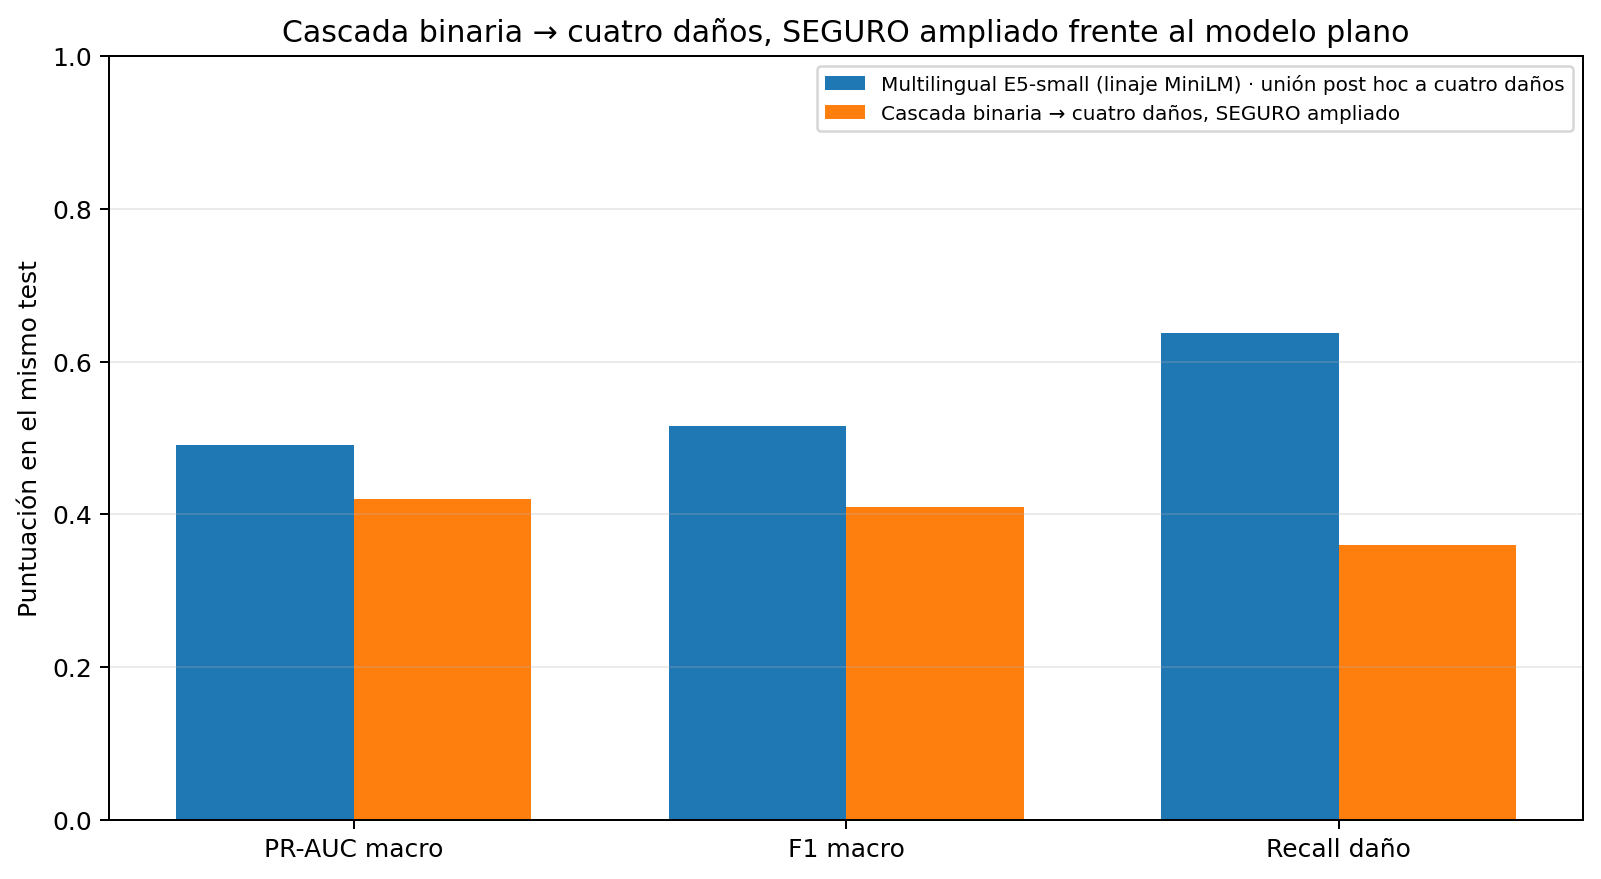

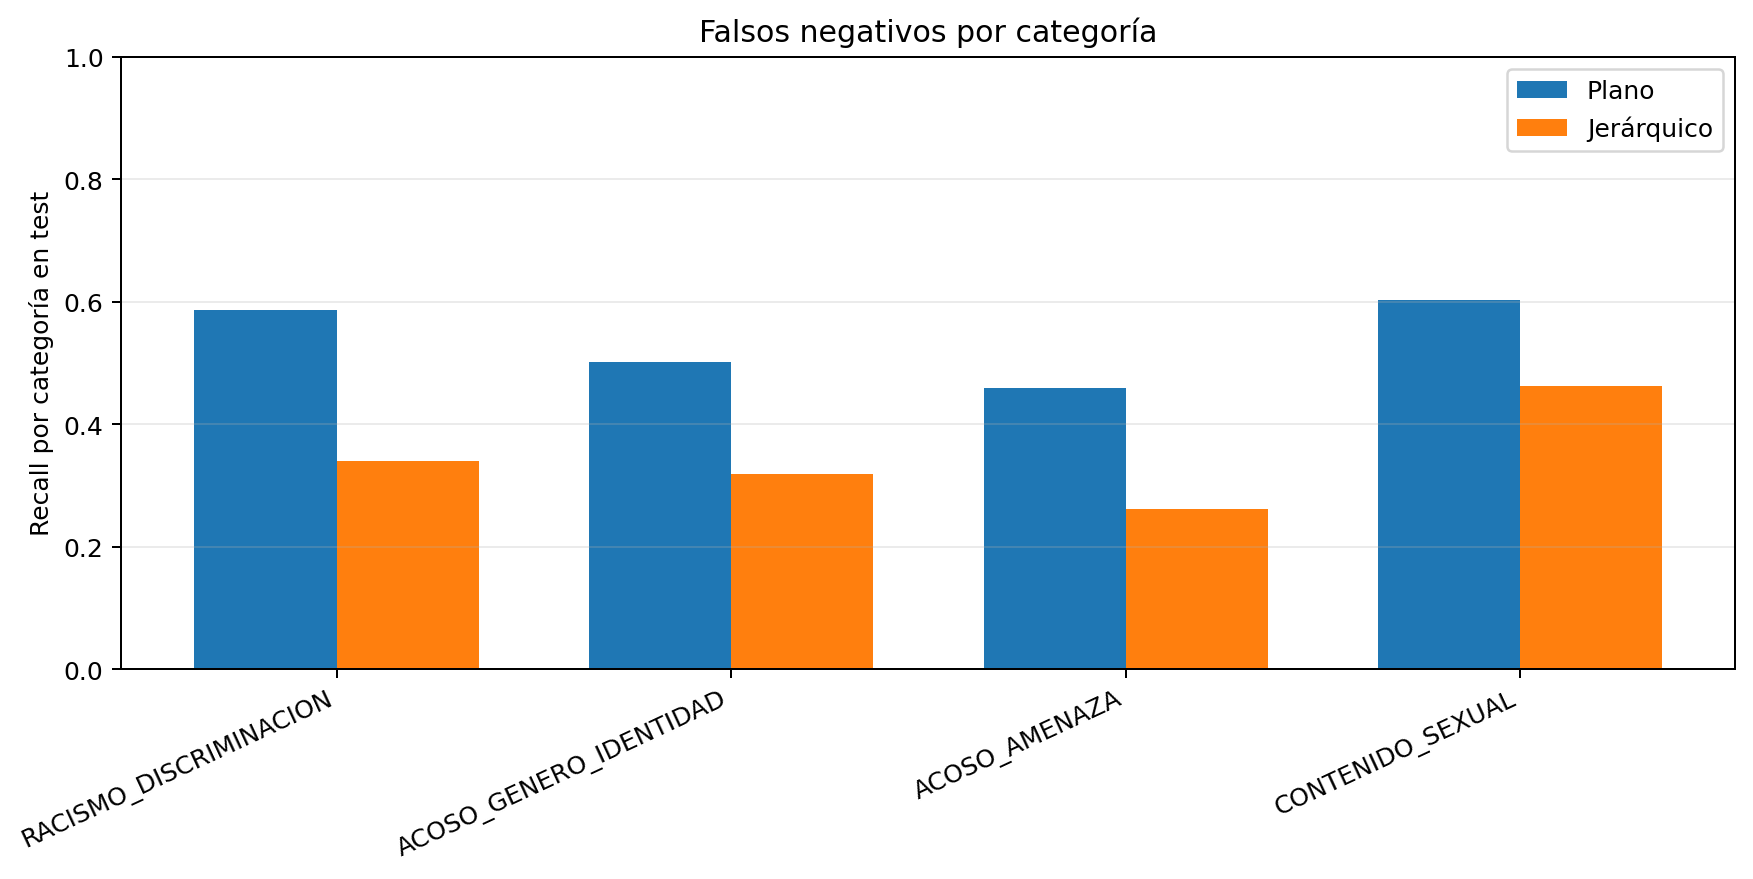

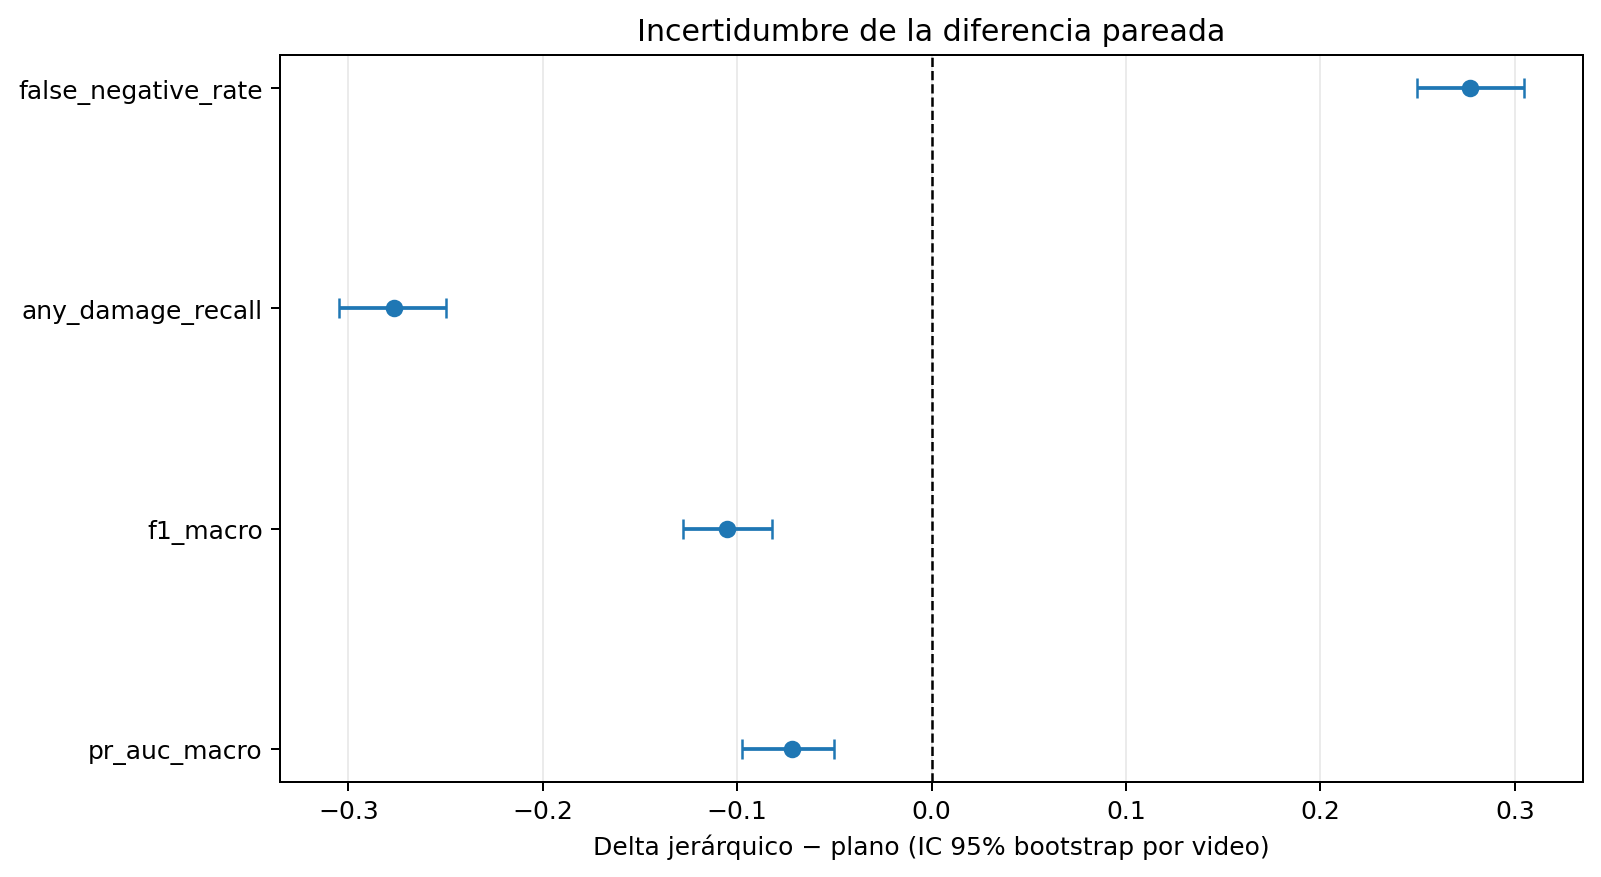

In [7]:
key = h4.CASCADE_EXTRA_SAFE_KEY if EXPANDED_SAFE_GATE else h4.CASCADE_KEY
tables = h4.load_experiment_tables(key)
display(tables['comparison'])
display(tables['categories'])
display(tables['bootstrap'])
display(pd.DataFrame([result['selective_operation']]))

figure_dir = h4.FIGURES_ROOT / key
for name in ['comparacion_global_test.png', 'recall_por_categoria_test.png', 'bootstrap_deltas_test.png']:
    display(Image(filename=str(figure_dir / name)))

In [8]:
display(Markdown(
    f'**Resultado reproducible:** `{h4.result_path(key).relative_to(ROOT)}`  \n'
    f'**Informe:** `{h4.report_path(key).relative_to(ROOT)}`  \n'
    f'**Modelos:** `{(h4.MODEL_ROOT / key).relative_to(ROOT)}`'
))

**Resultado reproducible:** `resultados/metricas/experimentos_jerarquicos_4/cascada_binaria_multietiqueta_4_seguros_ampliados/resultado.json`  
**Informe:** `resultados/INFORME_04_203_CASCADA_4_ETIQUETAS.md`  
**Modelos:** `modelos/experimentos_jerarquicos_4/cascada_binaria_multietiqueta_4_seguros_ampliados`

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Zhou, J., Ma, C., Long, D., Xu, G., Ding, N., Zhang, H., Xie, P., & Liu, G. (2020). Hierarchy-aware global model for hierarchical text classification. In *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics* (pp. 1106–1117). Association for Computational Linguistics. https://doi.org/10.18653/v1/2020.acl-main.104